In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Fish.csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [3]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [4]:
df['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [6]:
df['Species']=le.fit_transform(df['Species'])
df['Species']

0      0
1      0
2      0
3      0
4      0
      ..
154    5
155    5
156    5
157    5
158    5
Name: Species, Length: 159, dtype: int64

In [7]:
df['Species'].unique()

array([0, 4, 6, 1, 2, 3, 5])

In [8]:
df.dtypes

Species      int64
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

In [9]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

In [10]:
df['Weight']=df['Weight'].astype(int)

In [11]:
df['Length1']=df['Length1'].astype(int)

In [12]:
df['Length2']=df['Length2'].astype(int)

In [13]:
df['Length3']=df['Length3'].astype(int)

In [14]:
df['Height']=df['Height'].astype(int)

In [15]:
df['Width']=df['Width'].astype(int)

In [16]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,0,242,23,25,30,11,4
1,0,290,24,26,31,12,4
2,0,340,23,26,31,12,4
3,0,363,26,29,33,12,4
4,0,430,26,29,34,12,5
...,...,...,...,...,...,...,...
154,5,12,11,12,13,2,1
155,5,13,11,12,13,2,1
156,5,12,12,13,13,2,1
157,5,19,13,14,15,2,2


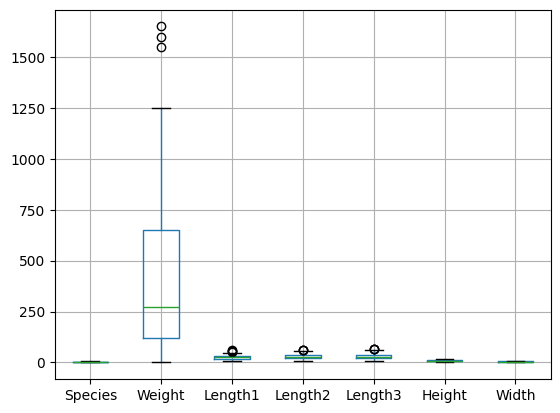

In [17]:
df.boxplot()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [21]:
df_Stand=pd.DataFrame(ss.fit_transform(df),columns=df.columns)

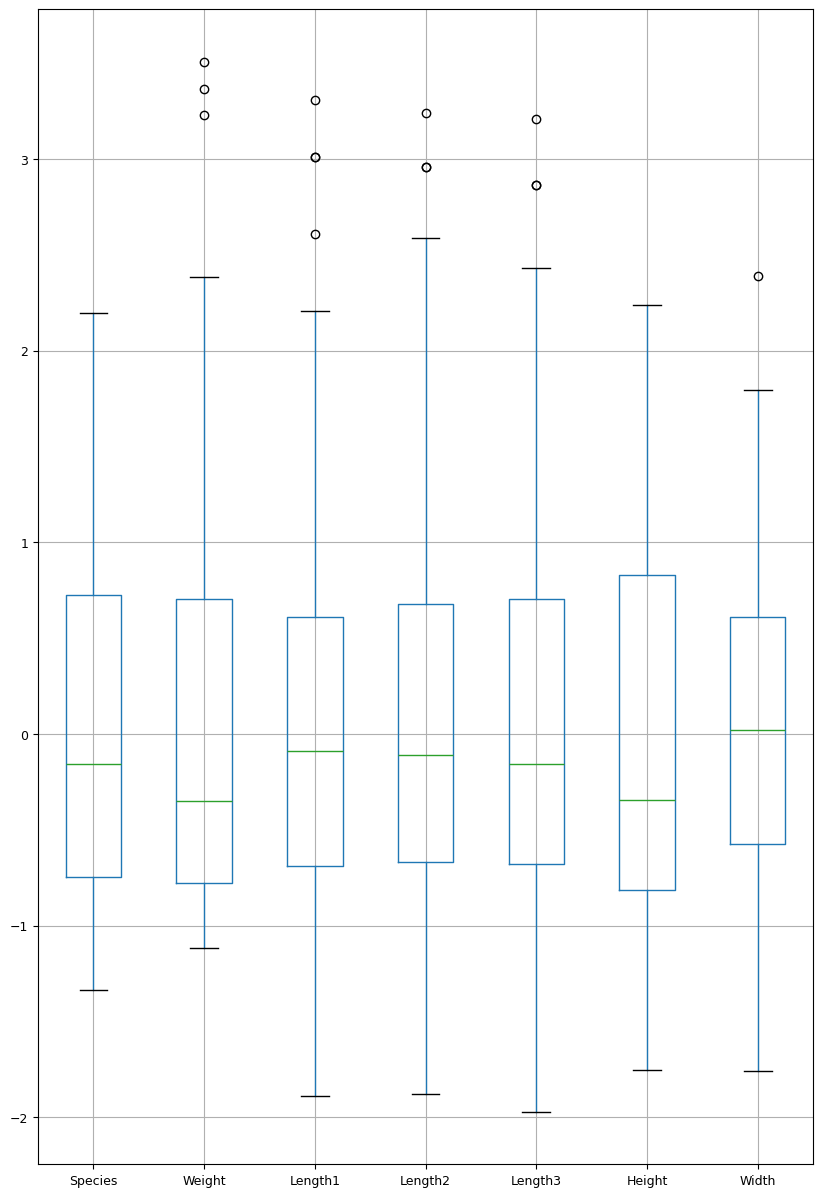

In [25]:
df_Stand.boxplot(fontsize=9,figsize=(10,15))
plt.show()

In [27]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,0,242,23,25,30,11,4
1,0,290,24,26,31,12,4
2,0,340,23,26,31,12,4
3,0,363,26,29,33,12,4
4,0,430,26,29,34,12,5
...,...,...,...,...,...,...,...
154,5,12,11,12,13,2,1
155,5,13,11,12,13,2,1
156,5,12,12,13,13,2,1
157,5,19,13,14,15,2,2


In [28]:
x=df.drop('Weight',axis=1)
x

,Species,Length1,Length2,Length3,Height,Width
0,0,23,25,30,11,4
1,0,24,26,31,12,4
2,0,23,26,31,12,4
3,0,26,29,33,12,4
4,0,26,29,34,12,5
...,...,...,...,...,...,...
154,5,11,12,13,2,1
155,5,11,12,13,2,1
156,5,12,13,13,2,1
157,5,13,14,15,2,2


In [29]:
y=df['Weight']
y

0      242
1      290
2      340
3      363
4      430
      ... 
154     12
155     13
156     12
157     19
158     19
Name: Weight, Length: 159, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
len(x_train)

127

In [32]:
len(x_test)

32

In [36]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [37]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_predict=lr.predict(x_test)

In [39]:
from sklearn.metrics import r2_score

In [41]:
lr_ac=r2_score(y_test,y_predict)*100
lr_ac

89.11457079375182

In [42]:

from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_predict) 
print("Mean Absolute Error:",mae)

Mean Absolute Error: 103.52801072279655
